# Saving and exporting

Every widget can be saved programmatically: its **state** as JSON, a **figure** as PNG/PDF/TIFF, and (for the volume widgets) a **standalone interactive HTML** viewer in either exact float32 or a smaller quantized uint8 pack. This page uses the same synthetic data as the other tutorials, so it runs anywhere.

In [1]:
import numpy as np, pathlib, tempfile
from quantem.widget import Show2D, Show3D

out = pathlib.Path(tempfile.mkdtemp(prefix='quantem_widget_save_'))

# small synthetic lattice (2D) and object-phase volume (3D)
size = 256
row, col = np.mgrid[0:size, 0:size]
image = sum(np.exp(-(((row - r0) ** 2 + (col - c0) ** 2)) / (2 * 3.0 ** 2))
            for r0 in range(12, size, 24) for c0 in range(12, size, 24)).astype(np.float32)
volume = np.stack([np.roll(image, k, axis=1) for k in range(32)]).astype(np.float32)
image.shape, volume.shape

((256, 256), (32, 256, 256))

## 1. Save widget state (JSON)

`save()` writes a small, versioned JSON capturing the current view (colormap, contrast, ROIs, zoom, ...). Reload it later to restore the same view.

In [2]:
show2d = Show2D(image, pixel_size=0.2, cmap='magma', offline=True)
state_path = show2d.save(str(out / 'view.json'))
state_path = out / 'view.json'
print('state:', state_path, '-', state_path.stat().st_size, 'bytes')

state: /tmp/claude-1000/quantem_widget_save_7dqwe5mi/view.json - 849 bytes


## 2. Save a figure (PNG)

`save_image()` writes the colormapped image directly, or a publication figure with a title, colorbar, and scale bar when you ask for them.

figure: /tmp/claude-1000/quantem_widget_save_7dqwe5mi/lattice.png - 299744 bytes


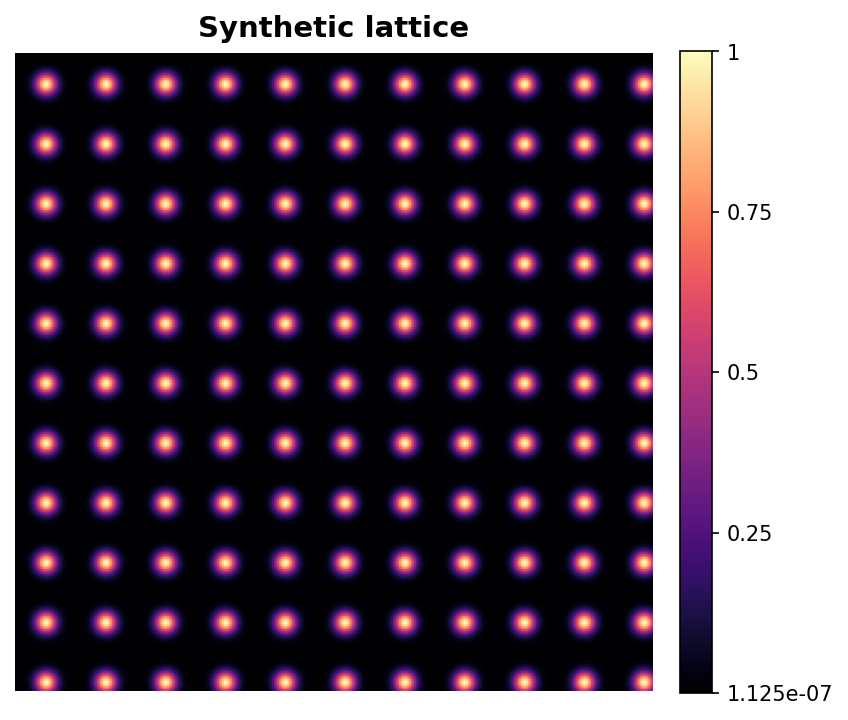

In [3]:
png_path = show2d.save_image(out / 'lattice.png', scalebar=True, colorbar=True, title='Synthetic lattice')
print('figure:', png_path, '-', png_path.stat().st_size, 'bytes')
from IPython.display import Image
Image(filename=str(png_path))

## 3. Export a standalone interactive HTML

`Show3D` and `Show3DSlices` can write a single self-contained HTML file that keeps the scrub interactive with no kernel. Two modes:

- **exact** (default): embeds float32 bytes, preserves numerical precision.
- **quantized**: embeds the uint8 offline pack plus global min/max - ~4x smaller,   visually identical after the colormap.

In [4]:
show3d = Show3D(volume, pixel_size=0.2, offline=True)
exact = show3d.export_html(out / 'volume_exact.html')
quant = show3d.export_html(out / 'volume_quantized.html', quantized=True)
for p in (exact, quant):
    print(f'{p.name:24s} {p.stat().st_size/1e6:6.2f} MB')

volume_exact.html         11.89 MB
volume_quantized.html      3.50 MB


## 4. Bundle exports into a zip

There is no special zip API - the exported files are ordinary files, so the standard library bundles them in a few lines.

In [5]:
import zipfile
bundle = out / 'widget_report.zip'
with zipfile.ZipFile(bundle, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in [state_path, png_path, exact, quant]:
        zf.write(p, arcname=p.name)
print('bundle:', bundle, '-', bundle.stat().st_size/1e6, 'MB')
print('contains:', zipfile.ZipFile(bundle).namelist())

bundle: /tmp/claude-1000/quantem_widget_save_7dqwe5mi/widget_report.zip - 1.185104 MB
contains: ['view.json', 'lattice.png', 'volume_exact.html', 'volume_quantized.html']


```{tip}
For embedding a widget in *these docs* (or any nbconvert/Jupyter Book page), construct it with `offline=True` and let the notebook bake the state - the same mechanism `export_html` uses, but inline in the page.
```